In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
import torch.utils.data as data


torch.manual_seed(1337)
np.random.seed(1337)
random.seed(1337)

In [3]:
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

In [4]:
def preprocess_data(dataset):
    data = (dataset.data / 255.0) - 0.5
    flattened_data = data.view(data.shape[0], -1)
    targets = dataset.targets
    return flattened_data, targets

x_train, y_train = preprocess_data(trainset)
x_test, y_test = preprocess_data(testset)

In [5]:
def parameters(sizes):
    total=0
    for i in range(len(sizes)-1):
        total+=sizes[i]*sizes[i+1]+sizes[i+1]
    
    return total


In [6]:
def uniform_network(P,k):
    #solve by approximation
    m=int(np.sqrt(P/(k+1)))
    return [m]*k


In [7]:
def adjusted_sizes(sizes,P):
    params=parameters(sizes)
    if params==0:
        return sizes
    scale=np.sqrt(P/params)

    lst=[int(x*scale)for x in sizes]
    adjusted=[]
    #hidden layers: minimum size = 10
    for i,x in enumerate(lst):
        if i<len(lst)-1 and i>0:
            adjusted.append(max(x,10))
        else:
            adjusted.append(x)
    return adjusted

In [8]:
def increasingNetwork(P,k):
    base_size=int(np.sqrt(P/k/784))
    sizes=[int(base_size*(.3*i+1))for i in range(k)]
    full_sizes=[784]+sizes+[10]
    params=parameters(full_sizes)
    if params>0:
        scale=np.sqrt(P/params)
        sizes=[max(10,int(s*scale))for s in sizes]
    return sizes

    return sizes

In [9]:
def decreasingNetwork(P,k):
    if k<2:
        return uniform_network(P,k)
    
    base=max(20,int(np.sqrt(P/(k*50))))

    sizes=[]
    for i in range(k):
        size=int(base*(.7**i))
        sizes.append(max(10,size))
    sizes.append(size)
    full=[784]+sizes+[10]
    params=parameters(full)
    scale=np.sqrt(P/params)
    sizes=[max(10,int(s*scale))for s in sizes]
        
    return sizes

In [10]:
def bottleneck_network(P,k):
    if k<3:
        return uniform_network(P,k)
    mid=k//2
    base=max(20,int(np.sqrt(P/k/500)))
    ratio=1
    sizes=[]
    for i in range(k):
        if i<=mid:
            ratio=1-.5*(i/mid)
        else:
            size=.5+.5*((i-mid)/(k-mid))
        sizes.append(max(10,int(base*ratio)))
    currentP=parameters([784]+sizes+[10])
    scale=np.sqrt(P/currentP)
    sizes=[max(10,int(s*scale))for s in sizes]
    return sizes    


In [11]:
class Flexible(nn.Module):
    def __init__(self,layer_sizes):
        super().__init__()
        self.layers=nn.ModuleList()
        for i in range(len(layer_sizes)-1):
            self.layers.append(nn.Linear(layer_sizes[i],layer_sizes[i+1]))
        
        self.activation=nn.Tanh()

    def forward(self, x):
        for layer in self.layers[:-1]:
            x=self.activation(layer(x))
        return self.layers[-1](x)
    def count_param(self):
        return sum(p.numel()for p in self.parameters)

In [12]:
def train_network_flexible(model,epochs=20,lr=.01,weight_decay=0.0):
    loss_function=nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    train_dataset = data.TensorDataset(x_train, y_train)
    train_loader = data.DataLoader(dataset=train_dataset, 
                                   batch_size=1024, shuffle=True)
    
    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        total_loss=0

        for x_batch, y_batch in train_loader:
            logits = model(x_batch)
            loss = loss_function(logits, y_batch)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        train_loss = total_loss / len(train_loader)
        train_losses.append(train_loss)

In [13]:
def testing_architect(name,sizes_func,P,k_vals,epochs=20,lr=.01,weight_decay=0.0):
    ks=[]
    train_losses=[]
    test_losses=[]
    params=[]
    size_list=[]
    for k in k_vals:
        sizes=sizes_func(P,k)
        sizes=[784]+sizes+[10]
        model=Flexible(sizes)
        actual_params=model.count_param(sizes)
        
        train_loss,test_loss=train_network_flexible(model,epochs=epochs,lr=lr,weight_decay=weight_decay)
        ks.append(k)
        params.append(actual_params)
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        size_list.append(sizes)
    return [ks,params,train_losses,test_losses,size_list]

In [14]:
def train_model(model,epochs=20,lr=.01,weight_decay=.0,batch_size=1024):
    loss_function=nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_dataset = data.TensorDataset(x_train, y_train)
    train_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(x_train, y_train),
        batch_size=batch_size,
        shuffle=True
    )    
    for epoch in range(epochs):
        # Training
        model.train()
        total_loss = 0
        for x_batch, y_batch in train_loader:
            logits = model(x_batch)
            loss = loss_function(logits, y_batch)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss+=loss.item()
        
        train_loss = total_loss/len(train_loader)
        model.eval()
        with torch.no_grad():
            logits = model(x_test)
            test_loss = loss_function(logits, y_test).item()
    return train_loss,test_loss

In [15]:
P=2e4
k=5

In [152]:
#uniform
hidden_sizes=uniform_network(P,k)
full_architect=[784]+hidden_sizes+[10]
print(f'parameters: {parameters(full_architect):,}')
model=Flexible(full_architect)
train_loss,test_loss=train_model(model, epochs=20, lr=0.01)
print(f"train loss: {train_loss:.4f}, test loss: {test_loss:.4f}")

parameters: 58,549
train loss: 1.6218, test loss: 1.5826


In [153]:
#decreasing
hidden_sizes=decreasingNetwork(P,k)
full_architect=[784]+hidden_sizes+[10]
print(f'parameters: {parameters(full_architect):,}')
model=Flexible(full_architect)
train_loss,test_loss=train_model(model, epochs=20, lr=0.01)
print(f"train loss: {train_loss:.4f}, test loss: {test_loss:.4f}")

parameters: 18,285
train loss: 2.2848, test loss: 2.2822


In [154]:
#increasing
hidden_sizes=increasingNetwork(P,k)
full_architect=[784]+hidden_sizes+[10]
print(f'parameters: {parameters(full_architect):,}')
model=Flexible(full_architect)
train_loss,test_loss=train_model(model, epochs=20, lr=0.01)
print(f"train loss: {train_loss:.4f}, test loss: {test_loss:.4f}")

parameters: 8,463
train loss: 1.8800, test loss: 1.8643


In [155]:
#bottleneck
hidden_sizes=bottleneck_network(P,k)
full_architect=[784]+hidden_sizes+[10]
print(f'parameters: {parameters(full_architect):,}')
model=Flexible(full_architect)
train_loss,test_loss=train_model(model, epochs=20, lr=0.01)
print(f"train loss: {train_loss:.4f}, test loss: {test_loss:.4f}")

parameters: 18,209


KeyboardInterrupt: 

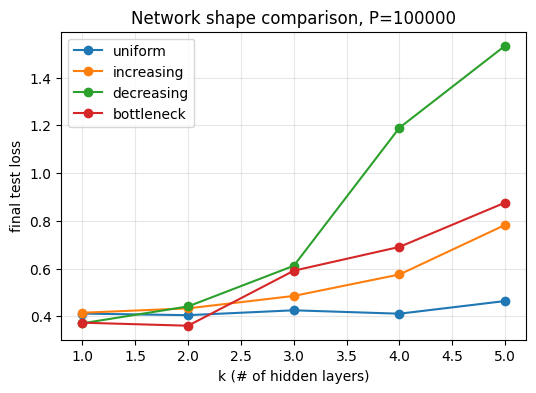

In [159]:
P = 100_000
k_values = [1, 2, 3, 4, 5]
epochs = 30
lr = 1e-2
wd = 0.0

INPUT_DIM = x_train.shape[1]
NUM_CLASSES = int(y_train.max().item() + 1)

architectures = {
    "uniform": uniform_network,
    "increasing": increasingNetwork,
    "decreasing": decreasingNetwork,
    "bottleneck": bottleneck_network,
}

results = {}

for name, fn in architectures.items():
    train_losses, test_losses = [], []
    for k in k_values:
        hidden = fn(P, k)
        if k>=4:
            epochs=40
        sizes = [INPUT_DIM] + hidden + [NUM_CLASSES]
        model = Flexible(sizes)
        tr_loss, te_loss = train_model(
            model, epochs=epochs, lr=lr, weight_decay=wd
        )
        train_losses.append(tr_loss)
        test_losses.append(te_loss)
    results[name] = (train_losses, test_losses)

# plot
plt.figure(figsize=(6,4))
for name, (train_losses, test_losses) in results.items():
    plt.plot(k_values, test_losses, marker="o", label=name)
plt.xlabel("k (# of hidden layers)")
plt.ylabel("final test loss")
plt.title(f"Network shape comparison, P={P}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Based on such results, the decreasing model ends up with having the greatest final test loss. However, all seem to underfit further than a small k. In a previous test, it converges to some value above 2. A likely reason is a limited m. That is, layer has too small neurons with a greater k. 

The decreasing model seems to perform the worst, while the uniform model seems the most solid. The increasing and bottleneck seem to perform similarly. 

Since it's technically troubling running further P and k (because of computational limits), no further test could be made.


In [157]:
def train_regularization(model, weight_decay=1e-3, epochs=20, lr=1e-2):
    loss_fn = nn.CrossEntropyLoss()
    opt = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    train_loader = data.DataLoader(data.TensorDataset(x_train, y_train), batch_size=1024, shuffle=True)
    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            logits=model(xb)
            loss = loss_fn(logits, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            
    model.eval()
    with torch.no_grad():
        train_loss = np.mean([loss_fn(model(xb), yb).item() for xb, yb in train_loader])
        test_loss = loss_fn(model(x_test), y_test).item()
    return train_loss, test_loss

model=Flexible([784,128,10])
train_loss,test_loss=train_regularization(model,weight_decay=1e-3,epochs=20,lr=1e-2)

In [158]:
print(train_loss,test_loss)

0.5353142614081755 0.515503466129303


Question 3
------------
Question 4

In [19]:
batch_sizes=[1,10,100,1000,10000,50000]
lrs=[1e-2,1e-3,1e-4]
results={}

for lr in lrs:
    losses=[]
    for bs in batch_sizes:
        model=Flexible([784,10])
        train_loss,test_loss=train_model(model,epochs=1,lr=lr,weight_decay=.0,batch_size=bs)
        losses.append(test_loss)
    results[lr]=losses


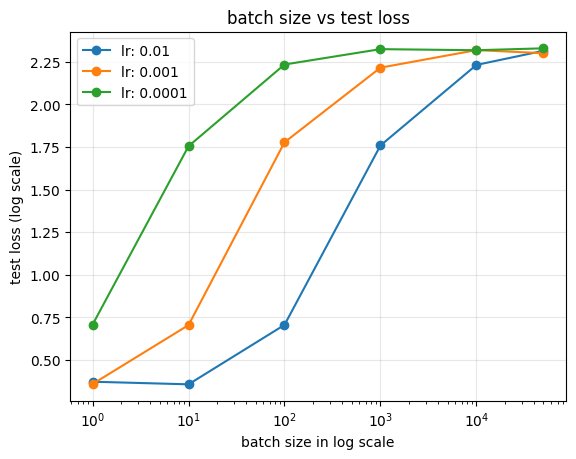

In [22]:

plt.figure()

for lr,loss in results.items():
    plt.plot(batch_sizes,loss,marker='o',label=f'lr: {lr}')

plt.xscale('log')
plt.xlabel('batch size in log scale')
plt.ylabel('test loss (log scale)')
plt.title('batch size vs test loss')
plt.legend()
plt.grid(True,alpha=.3)
plt.show()


With no hidden layers and a variety of batch sizes, it seems like smaller batch sizes and learning rates leads to a lower loss; after a small batch size, loss increses sharply. It could be explained by number of updates by batch size, i.e. smaller batch size gives greater updates per epoch, and vice versa. It couldn't be told for a limited computational power if such conclusion is necessarily holding. In theory, it's usually better to have a moderate batch size.

In [ ]:
import pandas as pd
optimizers = {
    "SGD": torch.optim.SGD,
    "Adam": torch.optim.Adam
}

activations = {
    "sigmoid": nn.Sigmoid(),
    "tanh": nn.Tanh(),
    "relu": nn.ReLU(),
    "elu": nn.ELU()
}

records=[]
for opt_name,opt_fn in optimizers.items():
    for act_name,act_fn in activations.items():
        model=Flexible([784,128,128,10])
        model.act=act_fn
        train,test=train_model(model,epochs=30,lr=1e-2,weight_decay=.0)
        records.append((opt_name,act_name,train,test))


ValueError: 2 columns passed, passed data had 4 columns

In [27]:
df = pd.DataFrame([
    {'Optimizer': o, 'Activation': a, 'Train Loss': tr, 'Test Loss': te}
    for (o, a, tr, te) in records
])
display(df)

,Optimizer,Activation,Train Loss,Test Loss
0,SGD,sigmoid,0.433197,0.413938
1,SGD,tanh,0.432231,0.414387
2,SGD,relu,0.435557,0.417740
3,SGD,elu,0.436483,0.419023
4,Adam,sigmoid,0.437598,0.418593
5,Adam,tanh,0.440279,0.422242
6,Adam,relu,0.436824,0.417396
7,Adam,elu,0.440939,0.421482


There isn't a significantly optimal optimizer. ReLU consistently performs better out of activations. In theory, Adam would outperform with a deeper model.